In [ ]:
# ─── SECTION 1: INSTALLS & IMPORTS ───────────────────────────────────────────
!pip install -q torch torchvision pillow matplotlib scikit-learn

import os
import json
import shutil
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter
from PIL import Image, ImageFilter, ImageStat

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
from torch.utils.data import DataLoader, random_split, Subset

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


In [ ]:
# ─── SECTION 2: MOUNT DRIVE & EXTRACT DATASET ────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

!ls "/content/drive/MyDrive"

# Copy and extract
!cp "/content/drive/MyDrive/dataset_rice.zip" /content/
!unzip -q /content/dataset_rice.zip -d /content/

DATASET_PATH = "/content/dataset_rice"

print("\nDataset structure:")
for cls in sorted(os.listdir(DATASET_PATH)):
    cls_path = os.path.join(DATASET_PATH, cls)
    if os.path.isdir(cls_path):
        count = len(os.listdir(cls_path))
        print(f"  {cls:>10}: {count} images")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
'1029(1).mp4'
 1765458838390.png
'(2022-ag-7726)  ML-Assignment.1.pdf'
'7PM | Python for Beginners | Recording Lectures'
 Assignment_1.ipynb
 Assignment_2.ipynb
 Book
'Colab Notebooks'
 crime_data.csv
'CV - IK (1).pdf'
'CV - IK (2).pdf'
'CV - IK (3).pdf'
'CV - IK.gdoc'
'CV - IK (Image).pdf'
'CV - IK.pdf'
'Dataset - Kaggle'
 dataset_rice.zip
'DFD 0.drawio'
'DFD 0.drawio.png'
 FYP.gdoc
 Hackathon
'HRM - Mid.gdoc'
 IMG_3585.MOV
'Interview Prep AI Project.zip'
 Izzah
'Level 1 DFD.drawio'
'LinkedIn Post.gdoc'
'NI Multisim 14.2 Professional (x86-x64)   Crack [FileCR].zip'
'Online Coffee Shop'
'Python Course Outline.gdoc'
 Python.gslides
 real_test.zip
 Resume.gdoc
 Schedule.xlsx
'Summer Schedule.gsheet'
 Testimonial.mp4
'Untitled document.gdoc'
 Weapons_Project.zip
'WhatsApp Image 2026-01-06 at 4.51.10 PM.jpeg'
'Wifi Extender Video (1).mp4'
'Wifi Extender Video.mp4

In [ ]:
# ─── SECTION 3: DATASET CLEANING ─────────────────────────────────────────────

VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tiff"}
MIN_SIZE_BYTES   = 2_000      # skip files under 2KB (likely corrupt/empty)
BLUR_THRESHOLD   = 50.0       # Laplacian variance below this = too blurry
STD_THRESHOLD    = 8.0        # pixel std below this = near-solid color image

removed = {"corrupt": [], "wrong_ext": [], "too_small": [],
           "blurry":  [], "solid_color": []}

def laplacian_variance(img_gray_np):
    """Measures image sharpness. Low value = blurry."""
    kernel = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]], dtype=np.float32)
    from scipy.signal import convolve2d
    conv = convolve2d(img_gray_np.astype(np.float32), kernel, mode='valid')
    return conv.var()

!pip install -q scipy   # needed for laplacian_variance

from scipy.signal import convolve2d  # re-import after install

print("Scanning dataset for bad images...\n")

total_scanned = 0
total_removed = 0

for cls in sorted(os.listdir(DATASET_PATH)):
    cls_path = os.path.join(DATASET_PATH, cls)
    if not os.path.isdir(cls_path):
        continue

    print(f"  Checking class: {cls}")
    files_in_cls = os.listdir(cls_path)

    for fname in files_in_cls:
        fpath = os.path.join(cls_path, fname)
        total_scanned += 1
        remove_reason = None

        # 1. Wrong extension
        ext = os.path.splitext(fname)[1].lower()
        if ext not in VALID_EXTENSIONS:
            remove_reason = "wrong_ext"

        # 2. File too small (likely empty/corrupt)
        elif os.path.getsize(fpath) < MIN_SIZE_BYTES:
            remove_reason = "too_small"

        else:
            # 3. Try to open and decode
            try:
                img = Image.open(fpath).convert("RGB")
                img.verify()            # checks file integrity
                img = Image.open(fpath).convert("RGB")   # re-open after verify
                img_np = np.array(img.convert("L"))      # grayscale for analysis

                # 4. Near-solid color (no useful texture)
                pixel_std = img_np.std()
                if pixel_std < STD_THRESHOLD:
                    remove_reason = "solid_color"

                # 5. Too blurry
                elif laplacian_variance(img_np) < BLUR_THRESHOLD:
                    remove_reason = "blurry"

            except Exception:
                remove_reason = "corrupt"

        if remove_reason:
            removed[remove_reason].append(fpath)
            os.remove(fpath)
            total_removed += 1

print(f"\nScan complete — {total_scanned} images scanned, {total_removed} removed")
print("\nBreakdown of removed images:")
for reason, paths in removed.items():
    if paths:
        print(f"  {reason:>12}: {len(paths)}")

print("\nDataset after cleaning:")
for cls in sorted(os.listdir(DATASET_PATH)):
    cls_path = os.path.join(DATASET_PATH, cls)
    if os.path.isdir(cls_path):
        count = len(os.listdir(cls_path))
        print(f"  {cls:>10}: {count} images")

A
A
A
Scanning dataset for bad images...

  Checking class: damaged
  Checking class: healthy

Scan complete — 2380 images scanned, 332 removed

Breakdown of removed images:
        blurry: 332

Dataset after cleaning:
     damaged: 1021 images
     healthy: 1027 images


Classes: ['damaged', 'healthy']


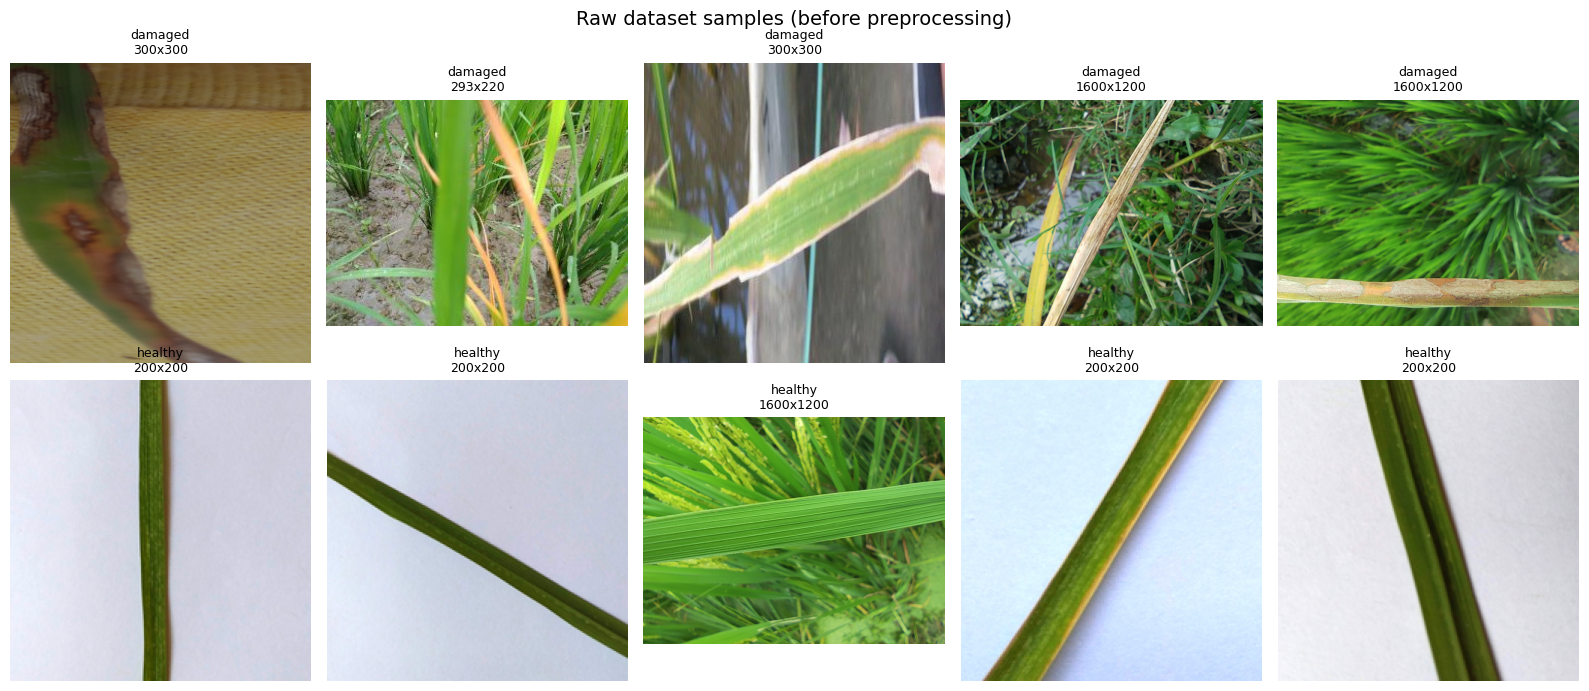

In [ ]:
# ─── SECTION 4: VISUALIZE RAW SAMPLES ────────────────────────────────────────
classes = sorted([
    d for d in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, d))
])
print("Classes:", classes)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle("Raw dataset samples (before preprocessing)", fontsize=14)

for row, cls in enumerate(classes):
    cls_path = os.path.join(DATASET_PATH, cls)
    sample_files = os.listdir(cls_path)[:5]
    for col, fname in enumerate(sample_files):
        img = Image.open(os.path.join(cls_path, fname)).convert("RGB")
        axes[row, col].imshow(img)
        axes[row, col].set_title(f"{cls}\n{img.size[0]}x{img.size[1]}", fontsize=9)
        axes[row, col].axis("off")

plt.tight_layout()
plt.savefig("sample_images.png", dpi=120)
plt.show()

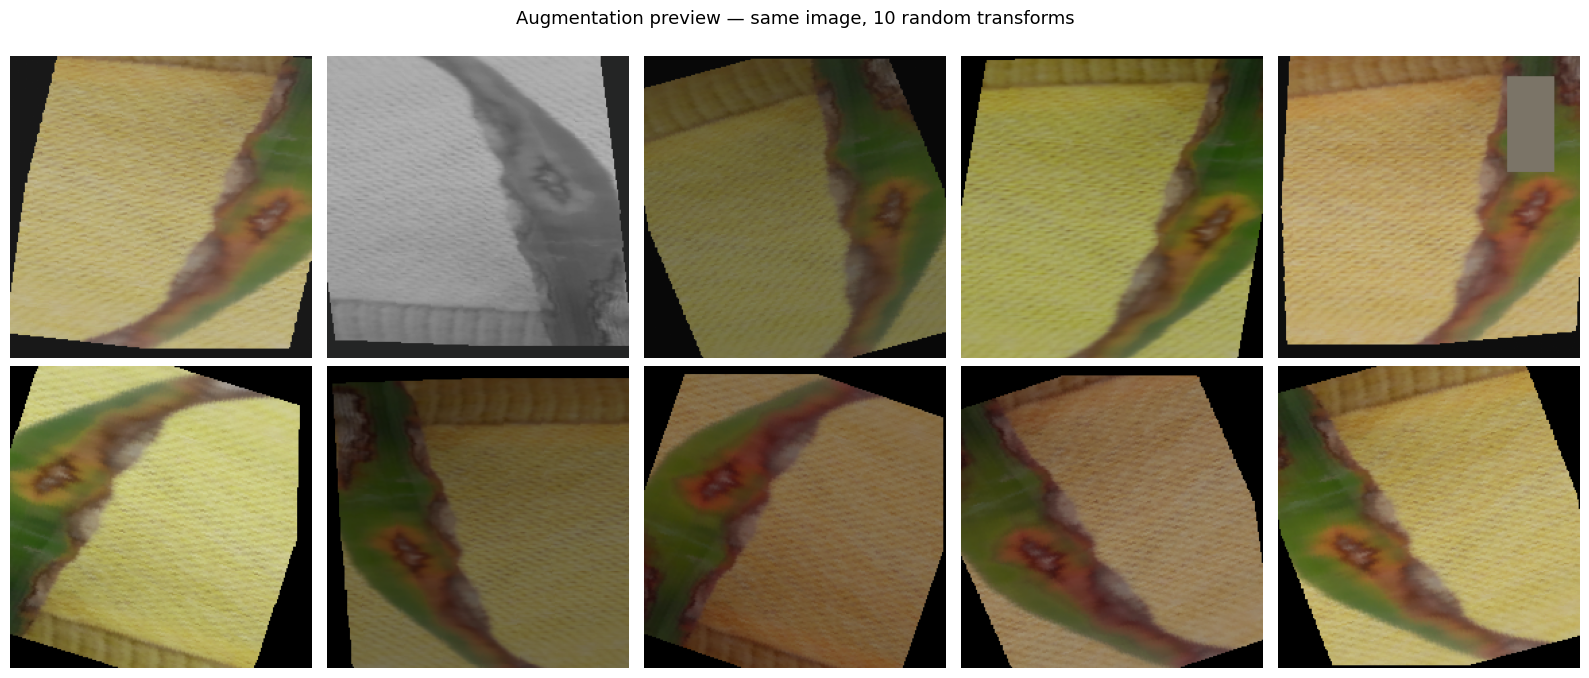

In [ ]:
# ─── SECTION 5: TRANSFORMS ───────────────────────────────────────────────────
# ImageNet normalization — correct for MobileNetV2 pretrained weights
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.75, 1.0)),  # random zoom
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=20),
    transforms.RandomAffine(degrees=0, shear=10, translate=(0.05, 0.05)),
    transforms.ColorJitter(
        brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05
    ),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
    transforms.RandomErasing(p=0.1, scale=(0.02, 0.1)),    # patch dropout
])

val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

# Same as val — no augmentation for test or inference
test_transform = val_transform

# Visualize what augmentation does to one image
sample_cls  = classes[0]
sample_file = os.listdir(os.path.join(DATASET_PATH, sample_cls))[0]
sample_path = os.path.join(DATASET_PATH, sample_cls, sample_file)
raw_img     = Image.open(sample_path).convert("RGB")

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle("Augmentation preview — same image, 10 random transforms", fontsize=13)
for i, ax in enumerate(axes.flat):
    aug = train_transform(raw_img)
    # un-normalize for display
    disp = aug.clone()
    for c, (m, s) in enumerate(zip(MEAN, STD)):
        disp[c] = disp[c] * s + m
    disp = disp.permute(1, 2, 0).numpy().clip(0, 1)
    ax.imshow(disp)
    ax.axis("off")

plt.tight_layout()
plt.savefig("augmentation_preview.png", dpi=120)
plt.show()

In [ ]:
# ─── SECTION 6: DATASET SPLIT — TRAIN / VAL / TEST ───────────────────────────
# Three separate ImageFolder objects — each with its own transform
# This is the correct fix for the transform-bleed bug
full_for_train = datasets.ImageFolder(DATASET_PATH, transform=train_transform)
full_for_val   = datasets.ImageFolder(DATASET_PATH, transform=val_transform)
full_for_test  = datasets.ImageFolder(DATASET_PATH, transform=test_transform)

CLASS_NAMES = full_for_train.classes
NUM_CLASSES  = len(CLASS_NAMES)
TOTAL        = len(full_for_train)

print(f"Total images : {TOTAL}")
print(f"Classes      : {CLASS_NAMES}")
print(f"Class indices: {full_for_train.class_to_idx}")

# 70% train | 15% val | 15% test
train_size = int(0.70 * TOTAL)
val_size   = int(0.15 * TOTAL)
test_size  = TOTAL - train_size - val_size

print(f"\nSplit sizes → train: {train_size}, val: {val_size}, test: {test_size}")

generator = torch.Generator().manual_seed(42)   # reproducible split
all_indices = list(range(TOTAL))
train_idx, remaining = random_split(all_indices, [train_size, TOTAL - train_size],
                                    generator=generator)
val_idx, test_idx = random_split(list(remaining), [val_size, test_size],
                                  generator=generator)

train_dataset = Subset(full_for_train, list(train_idx))
val_dataset   = Subset(full_for_val,   list(val_idx))
test_dataset  = Subset(full_for_test,  list(test_idx))

# Verify class distribution in each split
def split_distribution(subset, full_dataset, label):
    labels = [full_dataset.targets[i] for i in subset.indices]
    dist   = Counter(labels)
    print(f"{label}: ", {CLASS_NAMES[k]: v for k, v in sorted(dist.items())})

split_distribution(train_dataset, full_for_train, "Train")
split_distribution(val_dataset,   full_for_val,   "Val  ")
split_distribution(test_dataset,  full_for_test,  "Test ")

# Loaders
BATCH_SIZE   = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f"\nBatches → train: {len(train_loader)}, val: {len(val_loader)}, test: {len(test_loader)}")

Total images : 2048
Classes      : ['damaged', 'healthy']
Class indices: {'damaged': 0, 'healthy': 1}

Split sizes → train: 1433, val: 307, test: 308
Train:  {'damaged': 722, 'healthy': 711}
Val  :  {'damaged': 151, 'healthy': 156}
Test :  {'damaged': 148, 'healthy': 160}

Batches → train: 45, val: 10, test: 10


In [ ]:
# ─── SECTION 7: MODEL SETUP ───────────────────────────────────────────────────
weights = MobileNet_V2_Weights.DEFAULT
model   = mobilenet_v2(weights=weights)

# Replace classifier head for binary classification
model.classifier[1] = nn.Linear(model.last_channel, NUM_CLASSES)

# Phase 1: freeze backbone, train head only
for param in model.features.parameters():
    param.requires_grad = False

model = model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {total_params:,}")
print(f"Trainable (phase 1) : {trainable_params:,}  (backbone frozen)")

Total parameters    : 2,226,434
Trainable (phase 1) : 2,562  (backbone frozen)


In [ ]:
# ─── SECTION 8: TRAINING ──────────────────────────────────────────────────────
EPOCHS_FROZEN   = 5     # train head only
EPOCHS_FINETUNE = 20    # fine-tune entire network
EPOCHS_TOTAL    = EPOCHS_FROZEN + EPOCHS_FINETUNE

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=0.001
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

history = {
    "train_loss": [], "train_acc": [],
    "val_loss":   [], "val_acc":  []
}

best_val_acc  = 0.0
best_model_path = "/content/rice_classification_model.pth"

def run_epoch(loader, phase="train"):
    is_train = (phase == "train")
    model.train() if is_train else model.eval()

    running_loss = 0.0
    correct      = 0
    total        = 0

    with torch.set_grad_enabled(is_train):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            if is_train:
                loss.backward()
                optimizer.step()
            running_loss += loss.item()
            _, predicted  = torch.max(outputs, 1)
            total        += labels.size(0)
            correct      += (predicted == labels).sum().item()

    return running_loss / len(loader), 100.0 * correct / total


# ── Phase 1: head only ────────────────────────────────────────────────────────
print("═" * 60)
print("PHASE 1 — Training classifier head (backbone frozen)")
print("═" * 60)

for epoch in range(1, EPOCHS_FROZEN + 1):
    tr_loss, tr_acc   = run_epoch(train_loader, "train")
    val_loss, val_acc = run_epoch(val_loader,   "val")
    scheduler.step(val_loss)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        saved = " ← best saved"
    else:
        saved = ""

    print(f"Epoch {epoch:02d}/{EPOCHS_TOTAL} | "
          f"Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.2f}%{saved}")


# ── Phase 2: unfreeze all, fine-tune ─────────────────────────────────────────
print("\n" + "═" * 60)
print("PHASE 2 — Fine-tuning entire network (all layers unfrozen)")
print("═" * 60)

for param in model.features.parameters():
    param.requires_grad = True

trainable_now = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters now: {trainable_now:,}\n")

optimizer = optim.Adam(model.parameters(), lr=0.0001)   # lower lr
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

for epoch in range(EPOCHS_FROZEN + 1, EPOCHS_TOTAL + 1):
    tr_loss, tr_acc   = run_epoch(train_loader, "train")
    val_loss, val_acc = run_epoch(val_loader,   "val")
    scheduler.step(val_loss)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        saved = " ← best saved"
    else:
        saved = ""

    print(f"Epoch {epoch:02d}/{EPOCHS_TOTAL} | "
          f"Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.2f}%{saved}")

print(f"\nBest validation accuracy: {best_val_acc:.2f}%")

════════════════════════════════════════════════════════════
PHASE 1 — Training classifier head (backbone frozen)
════════════════════════════════════════════════════════════
Epoch 01/25 | Train Loss: 0.1741  Acc: 92.81% | Val Loss: 0.0511  Acc: 97.39% ← best saved
Epoch 02/25 | Train Loss: 0.1116  Acc: 96.44% | Val Loss: 0.0864  Acc: 97.72% ← best saved
Epoch 03/25 | Train Loss: 0.0746  Acc: 97.42% | Val Loss: 0.0374  Acc: 98.05% ← best saved
Epoch 04/25 | Train Loss: 0.0588  Acc: 97.77% | Val Loss: 0.0541  Acc: 98.70% ← best saved
Epoch 05/25 | Train Loss: 0.0980  Acc: 96.23% | Val Loss: 0.0173  Acc: 99.35% ← best saved

════════════════════════════════════════════════════════════
PHASE 2 — Fine-tuning entire network (all layers unfrozen)
════════════════════════════════════════════════════════════
Trainable parameters now: 2,226,434

Epoch 06/25 | Train Loss: 0.0459  Acc: 98.60% | Val Loss: 0.0131  Acc: 99.67% ← best saved
Epoch 07/25 | Train Loss: 0.0308  Acc: 99.37% | Val Loss: 0.

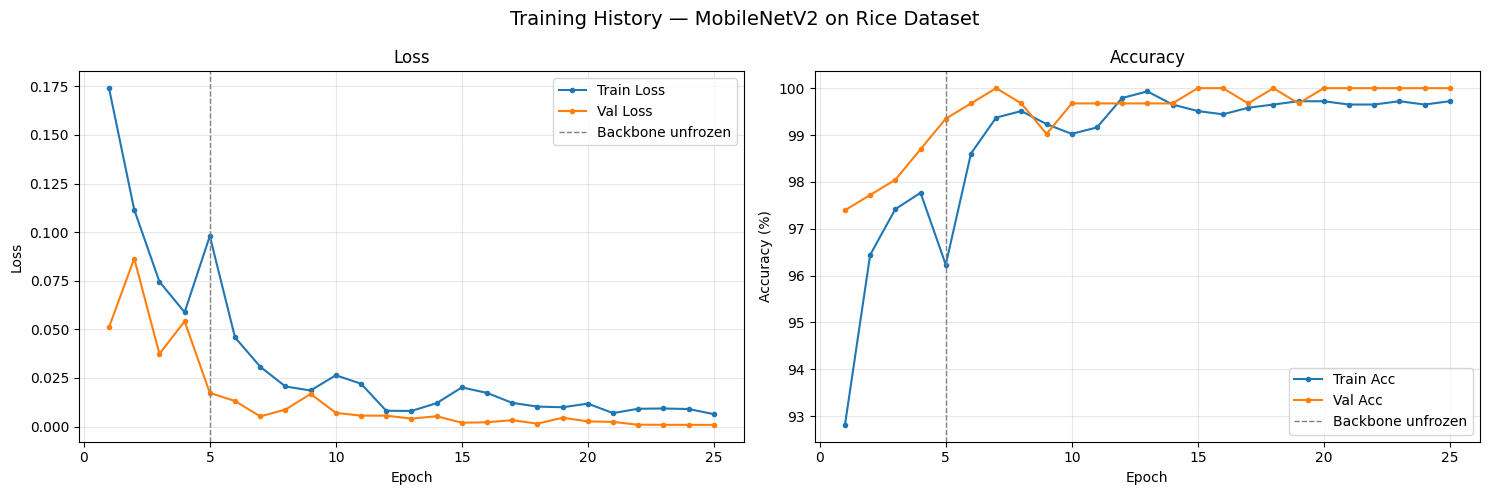

In [ ]:
# ─── SECTION 9: TRAINING CURVES ──────────────────────────────────────────────
epochs_range = range(1, EPOCHS_TOTAL + 1)
unfreeze_at  = EPOCHS_FROZEN  # vertical line here

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Training History — MobileNetV2 on Rice Dataset", fontsize=14)

ax1.plot(epochs_range, history["train_loss"], label="Train Loss", marker="o", markersize=3)
ax1.plot(epochs_range, history["val_loss"],   label="Val Loss",   marker="o", markersize=3)
ax1.axvline(unfreeze_at, color="gray", linestyle="--", linewidth=1, label="Backbone unfrozen")
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, history["train_acc"], label="Train Acc", marker="o", markersize=3)
ax2.plot(epochs_range, history["val_acc"],   label="Val Acc",   marker="o", markersize=3)
ax2.axvline(unfreeze_at, color="gray", linestyle="--", linewidth=1, label="Backbone unfrozen")
ax2.set_title("Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

TEST SET EVALUATION
              precision    recall  f1-score   support

     damaged       1.00      0.98      0.99       148
     healthy       0.98      1.00      0.99       160

    accuracy                           0.99       308
   macro avg       0.99      0.99      0.99       308
weighted avg       0.99      0.99      0.99       308

Overall Test Accuracy: 99.03%
ROC-AUC Score       : 0.9998


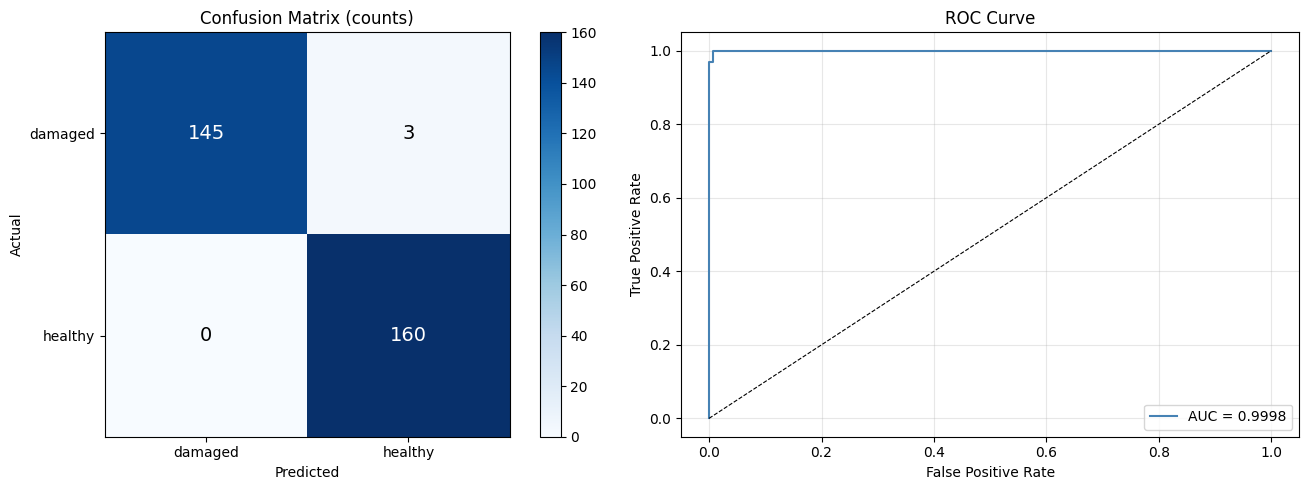


Misclassified: 3 / 308 images


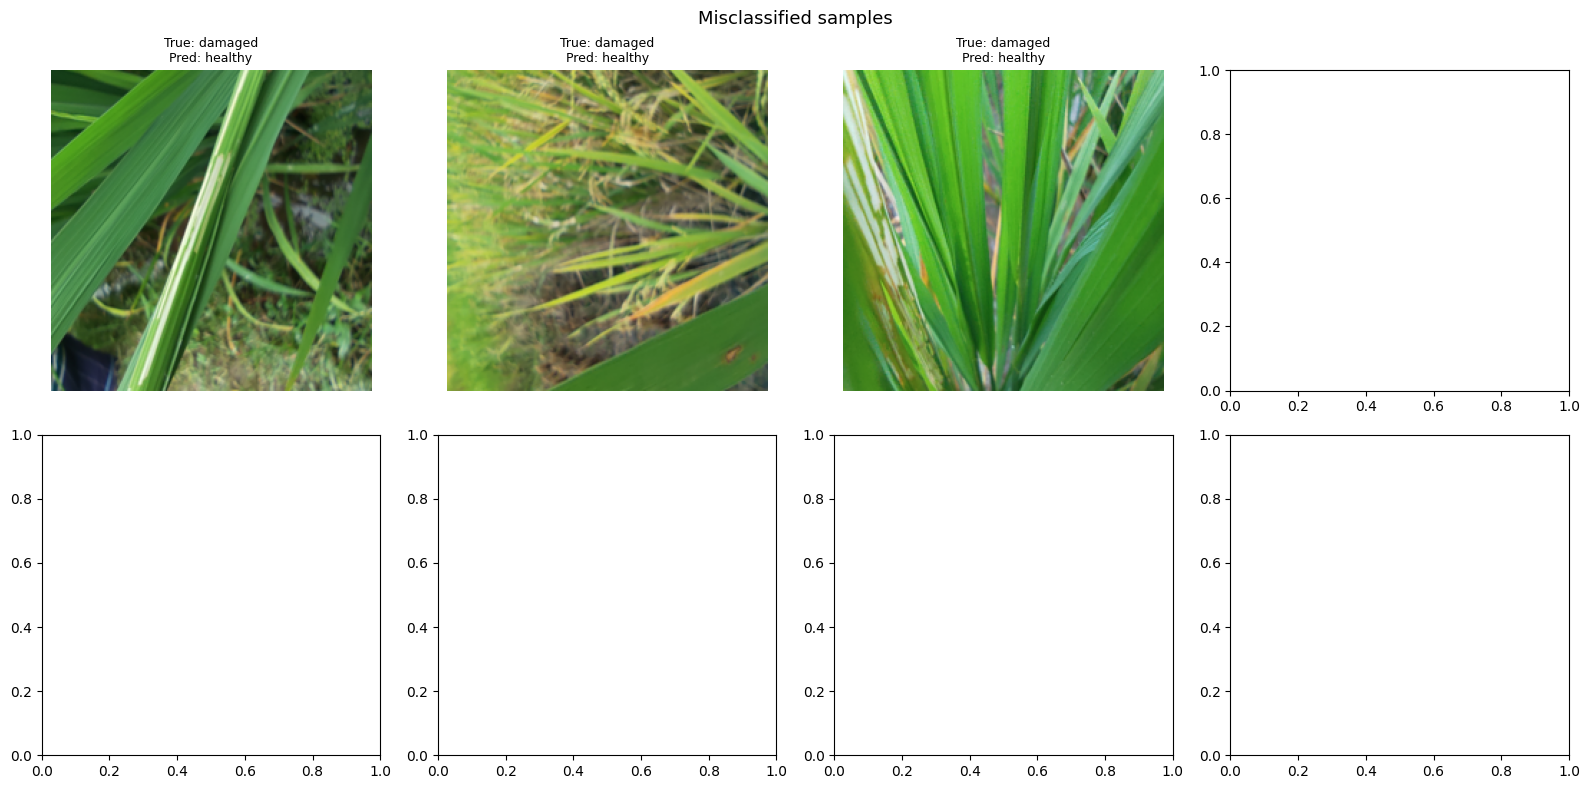

In [ ]:
# ─── SECTION 10: EVALUATION ON TEST SET ──────────────────────────────────────
# Load the best checkpoint
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

y_true      = []
y_pred      = []
y_probs     = []   # for ROC curve

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs   = model(images)
        probs     = F.softmax(outputs, dim=1)
        _, preds  = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_probs.extend(probs[:, 1].cpu().numpy())  # prob of class index 1

y_true  = np.array(y_true)
y_pred  = np.array(y_pred)
y_probs = np.array(y_probs)

# ── Classification report ─────────────────────────────────────────────────────
print("=" * 55)
print("TEST SET EVALUATION")
print("=" * 55)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

test_accuracy = 100.0 * np.sum(y_true == y_pred) / len(y_true)
print(f"Overall Test Accuracy: {test_accuracy:.2f}%")

try:
    auc = roc_auc_score(y_true, y_probs)
    print(f"ROC-AUC Score       : {auc:.4f}")
except Exception as e:
    print("ROC-AUC skipped:", e)

# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
im = axes[0].imshow(cm, cmap="Blues")
plt.colorbar(im, ax=axes[0])
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(CLASS_NAMES)
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(CLASS_NAMES)
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")
axes[0].set_title("Confusion Matrix (counts)")
for i in range(2):
    for j in range(2):
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        axes[0].text(j, i, str(cm[i, j]), ha="center", va="center",
                     fontsize=14, color=color)

# ROC curve
try:
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    axes[1].plot(fpr, tpr, label=f"AUC = {auc:.4f}", color="steelblue")
    axes[1].plot([0, 1], [0, 1], "k--", linewidth=0.8)
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title("ROC Curve")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
except Exception:
    axes[1].text(0.3, 0.5, "ROC not available\n(check class labels)")
    axes[1].axis("off")

plt.tight_layout()
plt.savefig("evaluation_results.png", dpi=150)
plt.show()

# ── Show misclassified samples ────────────────────────────────────────────────
wrong_indices = np.where(y_true != y_pred)[0]
print(f"\nMisclassified: {len(wrong_indices)} / {len(y_true)} images")

if len(wrong_indices) > 0:
    show_n = min(8, len(wrong_indices))
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle("Misclassified samples", fontsize=13)
    for ax, wi in zip(axes.flat, wrong_indices[:show_n]):
        # get image from test_dataset
        img_tensor, _ = test_dataset[wi]
        # un-normalize
        disp = img_tensor.clone()
        for c, (m, s) in enumerate(zip(MEAN, STD)):
            disp[c] = disp[c] * s + m
        disp = disp.permute(1, 2, 0).numpy().clip(0, 1)
        ax.imshow(disp)
        ax.set_title(f"True: {CLASS_NAMES[y_true[wi]]}\n"
                     f"Pred: {CLASS_NAMES[y_pred[wi]]}", fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.savefig("misclassified.png", dpi=120)
    plt.show()

In [ ]:
# ─── SECTION 11: SAVE MODEL & CLASS NAMES ────────────────────────────────────
from google.colab import files

# Save final model (last epoch weights)
FINAL_MODEL_PATH = "/content/rice_damage_model_final.pth"
torch.save(model.state_dict(), FINAL_MODEL_PATH)

# Save class names so inference knows the label order
CLASS_JSON_PATH = "/content/classes.json"
with open(CLASS_JSON_PATH, "w") as f:
    json.dump(CLASS_NAMES, f)

print("Saved files:")
print(f"  Best model  : {best_model_path}")
print(f"  Final model : {FINAL_MODEL_PATH}")
print(f"  Classes     : {CLASS_JSON_PATH}")
print(f"  Class order : {CLASS_NAMES}")
print(f"\n  → class index 0 = '{CLASS_NAMES[0]}'")
print(f"  → class index 1 = '{CLASS_NAMES[1]}'")

# Download everything
files.download(best_model_path)
files.download(FINAL_MODEL_PATH)
files.download(CLASS_JSON_PATH)
files.download("training_curves.png")
files.download("evaluation_results.png")

Saved files:
  Best model  : /content/rice_classification_model.pth
  Final model : /content/rice_damage_model_final.pth
  Classes     : /content/classes.json
  Class order : ['damaged', 'healthy']

  → class index 0 = 'damaged'
  → class index 1 = 'healthy'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# import os
# import hashlib

# def get_hash(image_path):
#     with open(image_path, 'rb') as f:
#         return hashlib.md5(f.read()).hexdigest()

# def get_all_hashes(folder):
#     hashes = {}
#     for root, _, files in os.walk(folder):
#         for file in files:
#             path = os.path.join(root, file)
#             hashes[path] = get_hash(path)
#     return hashes

# train_hashes = get_all_hashes("data/train")
# val_hashes   = get_all_hashes("data/val")
# test_hashes  = get_all_hashes("data/test")

# # Check duplicates
# train_vals = set(train_hashes.values())
# val_vals   = set(val_hashes.values())
# test_vals  = set(test_hashes.values())

# print("Train ∩ Val:", len(train_vals & val_vals))
# print("Train ∩ Test:", len(train_vals & test_vals))
# print("Val ∩ Test:", len(val_vals & test_vals))

Train ∩ Val: 0
Train ∩ Test: 0
Val ∩ Test: 0


Using model already loaded in this session.

Class names: ['damaged', 'healthy']
Damage threshold: 3 or more images damaged → CROP IS DAMAGED

Upload exactly 6 rice leaf images for testing:


Saving aug_0_16_jpg.rf.abcf41113ecb863cc3d4eac649438b44.jpg to aug_0_16_jpg.rf.abcf41113ecb863cc3d4eac649438b44.jpg
Saving aug_0_22_jpg.rf.9d64e0b9c1b0c2a7295f97a98fe05e6d.jpg to aug_0_22_jpg.rf.9d64e0b9c1b0c2a7295f97a98fe05e6d.jpg
Saving aug_0_47_jpg.rf.243ab699d102ebc74446de3b9da709f1.jpg to aug_0_47_jpg.rf.243ab699d102ebc74446de3b9da709f1.jpg
Saving aug_0_63_jpg.rf.594d8ce7c19603104c7325a1deb4b82b.jpg to aug_0_63_jpg.rf.594d8ce7c19603104c7325a1deb4b82b.jpg
Saving aug_0_65_jpg.rf.3b09cd0a1da3264deeffe7417cbbd4a1.jpg to aug_0_65_jpg.rf.3b09cd0a1da3264deeffe7417cbbd4a1.jpg
Saving aug_0_66_jpg.rf.9be735354b6fa41873b6ee050cd83609.jpg to aug_0_66_jpg.rf.9be735354b6fa41873b6ee050cd83609.jpg
Running classifier on 6 images...

Per-image results:
---------------------------------------------
  Image 1: aug_0_16_jpg.rf.abcf41113ecb863cc3d4eac649438b44.jpg
           → DAMAGED  |  confidence: 100.0%
  Image 2: aug_0_22_jpg.rf.9d64e0b9c1b0c2a7295f97a98fe05e6d.jpg
           → HEALTHY  |  confide

/tmp/ipykernel_8819/3394624094.py:157: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8819/3394624094.py:158: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("test_results.png", dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


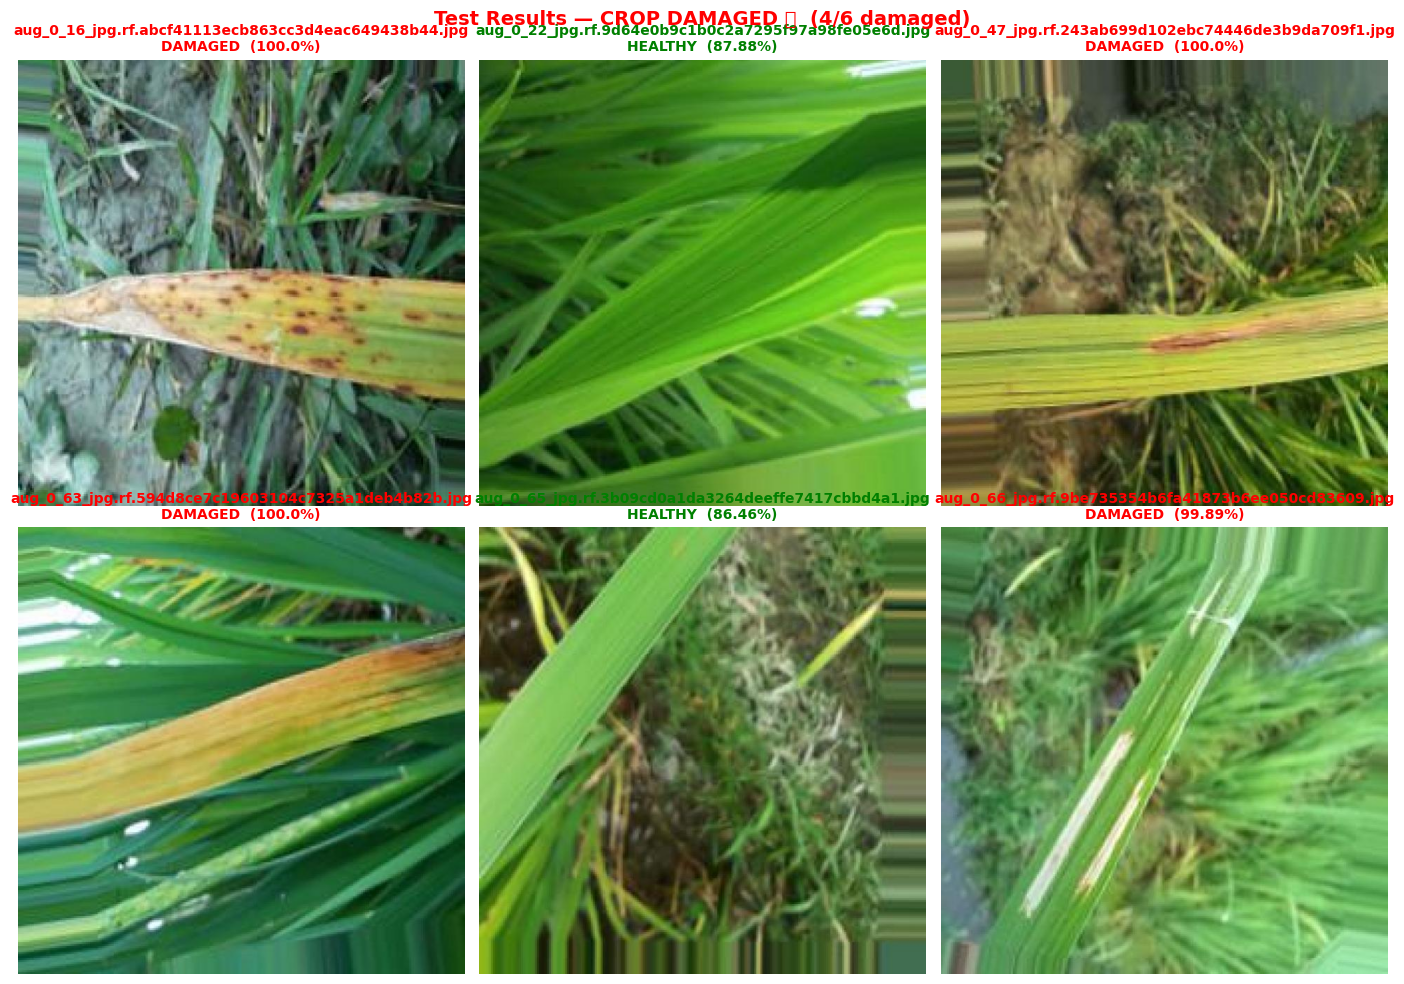

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ─── SECTION 12: TESTING — UPLOAD 6 IMAGES ───────────────────────────────────
# This section is self-contained. You can run it independently by loading
# the saved model first (the block below handles both cases).

from google.colab import files as colab_files
import torch, json
import torch.nn.functional as F
from torchvision import transforms
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# ── Constants ─────────────────────────────────────────────────────────────────
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]
DAMAGE_THRESHOLD = 3   # if this many or more images are damaged → crop is damaged

inference_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

# ── Load model (uses already-trained model if in same session) ────────────────
def load_inference_model(model_path, class_names, device):
    m = mobilenet_v2(weights=None)
    m.classifier[1] = __import__('torch').nn.Linear(m.last_channel, len(class_names))
    m.load_state_dict(__import__('torch').load(model_path, map_location=device))
    m = m.to(device)
    m.eval()
    return m

device = __import__('torch').device("cuda" if __import__('torch').cuda.is_available() else "cpu")

# Use model already in memory if available, otherwise load from file
try:
    _ = model
    inference_model = model
    print("Using model already loaded in this session.")
except NameError:
    print("Model not in memory. Loading from file...")
    print("Upload your rice_damage_model_final.pth first:")
    uploaded_model = colab_files.upload()
    model_fname = list(uploaded_model.keys())[0]

    print("Upload classes.json:")
    uploaded_json = colab_files.upload()
    json_fname = list(uploaded_json.keys())[0]

    with open(json_fname) as f:
        CLASS_NAMES = json.load(f)

    inference_model = load_inference_model(model_fname, CLASS_NAMES, device)
    print("Model loaded.")

print(f"\nClass names: {CLASS_NAMES}")
print(f"Damage threshold: {DAMAGE_THRESHOLD} or more images damaged → CROP IS DAMAGED\n")

# ── Upload exactly 6 images ───────────────────────────────────────────────────
print("=" * 55)
print("Upload exactly 6 rice leaf images for testing:")
print("=" * 55)
uploaded_imgs = colab_files.upload()

if len(uploaded_imgs) != 6:
    print(f"WARNING: You uploaded {len(uploaded_imgs)} image(s). Expected 6.")
    print("Proceeding with the images you uploaded...\n")

# ── Preprocess & predict each image ──────────────────────────────────────────
image_names   = list(uploaded_imgs.keys())
results       = []   # list of dicts: {name, label, confidence, tensor}

print(f"Running classifier on {len(image_names)} images...\n")

for img_name in image_names:
    img = Image.open(img_name).convert("RGB")
    tensor = inference_transform(img).unsqueeze(0).to(device)

    with __import__('torch').no_grad():
        output      = inference_model(tensor)
        probs       = F.softmax(output, dim=1)
        confidence, pred_idx = __import__('torch').max(probs, 1)

    label = CLASS_NAMES[pred_idx.item()]
    conf  = round(confidence.item() * 100, 2)

    results.append({
        "name":       img_name,
        "label":      label,
        "confidence": conf,
        "img":        img,
        "damaged":    label.lower() == "damaged"
    })

# ── Print per-image results ───────────────────────────────────────────────────
print("Per-image results:")
print("-" * 45)
damaged_count = 0
for i, r in enumerate(results, 1):
    status = "DAMAGED" if r["damaged"] else "HEALTHY"
    print(f"  Image {i}: {r['name']}")
    print(f"           → {status}  |  confidence: {r['confidence']}%")
    if r["damaged"]:
        damaged_count += 1

print("-" * 45)
print(f"Damaged images : {damaged_count} / {len(results)}")
print(f"Healthy images : {len(results) - damaged_count} / {len(results)}")

# ── Final verdict ─────────────────────────────────────────────────────────────
print("\n" + "=" * 55)
if damaged_count >= DAMAGE_THRESHOLD:
    avg_conf = round(
        sum(r["confidence"] for r in results if r["damaged"]) / damaged_count, 2
    )
    print("VERDICT: CROP IS DAMAGED")
    print(f"         {damaged_count} out of {len(results)} images classified as damaged.")
    print(f"         Average confidence on damaged images: {avg_conf}%")
else:
    avg_conf = round(
        sum(r["confidence"] for r in results if not r["damaged"]) / max(1, len(results) - damaged_count), 2
    )
    print("VERDICT: CROP IS HEALTHY")
    print(f"         Only {damaged_count} out of {len(results)} images classified as damaged.")
    print(f"         Average confidence on healthy images: {avg_conf}%")
print("=" * 55)

# ── Visual grid of all 6 images with their labels ────────────────────────────
cols = 3
rows = int(np.ceil(len(results) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
fig.suptitle(
    f"Test Results — {'CROP DAMAGED ❌' if damaged_count >= DAMAGE_THRESHOLD else 'CROP HEALTHY ✓'}  "
    f"({damaged_count}/{len(results)} damaged)",
    fontsize=14, fontweight="bold",
    color="red" if damaged_count >= DAMAGE_THRESHOLD else "green"
)

for ax, r in zip(axes.flat, results):
    ax.imshow(r["img"])
    color = "red" if r["damaged"] else "green"
    ax.set_title(
        f"{r['name']}\n{r['label'].upper()}  ({r['confidence']}%)",
        fontsize=10, color=color, fontweight="bold"
    )
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)
    ax.axis("off")

# hide unused axes if fewer than 6 images
for ax in axes.flat[len(results):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig("test_results.png", dpi=150)
plt.show()

colab_files.download("test_results.png")